# Environment Setup & Dependencies

In [17]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import time
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="darkgrid")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


# Reading the Data

In [2]:
PETS_DIR = Path("data/pets")
assert PETS_DIR.exists(), "Dataset not found. Run `python download_data.py` first."

full_dataset = datasets.ImageFolder(PETS_DIR)
class_names = full_dataset.classes
print(len(class_names), "breeds |", len(full_dataset), "images")

46 breeds | 8847 images


# Train-Test Split

In [3]:
IMG_SIZE = 224
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
eval_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

In [4]:
train_full = datasets.ImageFolder(PETS_DIR, transform=train_tfms)
eval_full = datasets.ImageFolder(PETS_DIR, transform=eval_tfms)

targets = np.array(full_dataset.targets)
idx = np.arange(len(targets))
train_idx, temp_idx = train_test_split(idx, test_size=0.3, stratify=targets, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=targets[temp_idx], random_state=42)

train_ds = Subset(train_full, train_idx)
val_ds = Subset(eval_full, val_idx)
test_ds = Subset(eval_full, test_idx)
print("Train:", len(train_ds), "| Val:", len(val_ds), "| Test:", len(test_ds))

Train: 6192 | Val: 1327 | Test: 1328


In [5]:
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)

# Train the Model

In [6]:
num_classes = len(class_names)

model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)   # new head for our breeds
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [7]:
scaler = torch.cuda.amp.GradScaler()

def run_epoch(loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0

    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            with torch.autocast("cuda", dtype=torch.float16):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if training:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)

    return total_loss / total, correct / total

In [8]:
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val = 0.0

def fit(epochs, lr):
    global best_val
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(train_loader, optimizer)
        val_loss, val_acc = run_epoch(val_loader)

        for key, value in zip(history, [train_loss, val_loss, train_acc, val_acc]):
            history[key].append(value)
        print(f"Epoch {epoch}/{epochs} | train acc {train_acc:.3f} | val acc {val_acc:.3f} | val loss {val_loss:.3f}")

        if val_acc > best_val:
            best_val = val_acc
            os.makedirs("models", exist_ok=True)
            torch.save(model.state_dict(), "models/best_checkpoint.pth")

In [15]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
for p in model.parameters():
    p.requires_grad = True

t0 = time.time()
for i, (images, labels) in enumerate(train_loader):
    if i == 20:
        break
    with torch.autocast("cuda", dtype=torch.float16):
        loss = criterion(model(images.to(device)), labels.to(device))
    optimizer.zero_grad()
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
elapsed = time.time() - t0
print(f"20 batches: {elapsed:.0f}s -> about {elapsed / 20 * len(train_loader) / 60:.1f} min per epoch")

20 batches: 5s -> about 0.8 min per epoch


### Stage 1: train only the new final layer

In [14]:
for param in model.features.parameters():
    param.requires_grad = False

fit(epochs=3, lr=1e-3)

Epoch 1/3 | train acc 0.642 | val acc 0.839 | val loss 1.375
Epoch 2/3 | train acc 0.826 | val acc 0.864 | val loss 1.240
Epoch 3/3 | train acc 0.865 | val acc 0.880 | val loss 1.189


### Stage 2: fine-tune the whole network

In [16]:
for param in model.features.parameters():
    param.requires_grad = True

fit(epochs=5, lr=1e-4)

Epoch 1/5 | train acc 0.907 | val acc 0.913 | val loss 1.034
Epoch 2/5 | train acc 0.950 | val acc 0.929 | val loss 0.990
Epoch 3/5 | train acc 0.966 | val acc 0.931 | val loss 0.982
Epoch 4/5 | train acc 0.979 | val acc 0.936 | val loss 0.963
Epoch 5/5 | train acc 0.989 | val acc 0.928 | val loss 0.956


In [18]:
model.load_state_dict(torch.load("models/best_checkpoint.pth", map_location=device))

_, best_acc = run_epoch(val_loader)
print(f"Best checkpoint loaded | validation accuracy: {best_acc:.3f}")

Best checkpoint loaded | validation accuracy: 0.936


# Data Visualization

In [19]:
@torch.no_grad()
def predict_loader(loader):
    model.eval()
    preds, labels_all = [], []
    for images, labels in loader:
        preds.append(model(images.to(device)).argmax(1).cpu())
        labels_all.append(labels)
    return torch.cat(preds).numpy(), torch.cat(labels_all).numpy()

y_pred, y_true = predict_loader(test_loader)

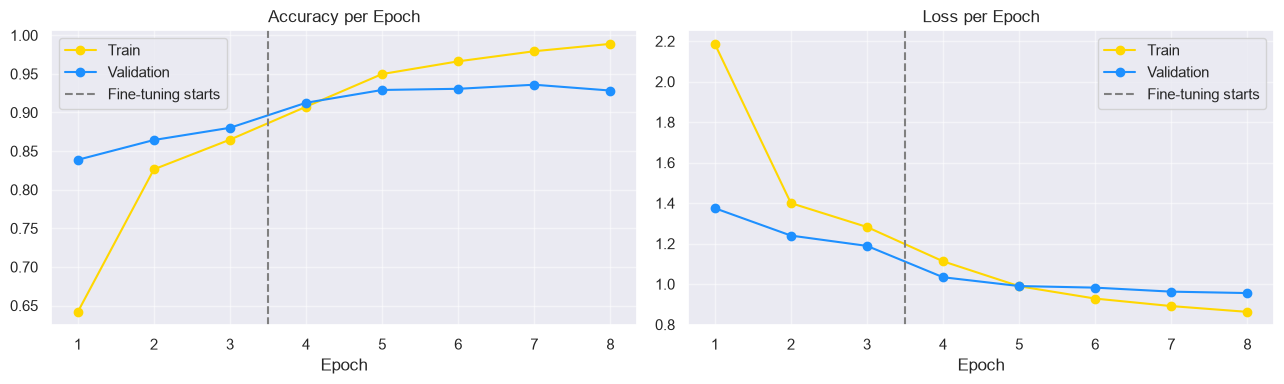

In [20]:
h = {k: v[-8:] for k, v in history.items()}          # 3 head-only epochs + 5 fine-tuning epochs
epochs = range(1, len(h["val_acc"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, key, title in [(axes[0], "acc", "Accuracy per Epoch"), (axes[1], "loss", "Loss per Epoch")]:
    ax.plot(epochs, h[f"train_{key}"], marker="o", color="gold", label="Train")
    ax.plot(epochs, h[f"val_{key}"], marker="o", color="dodgerblue", label="Validation")
    ax.axvline(3.5, color="gray", linestyle="--", label="Fine-tuning starts")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.show()

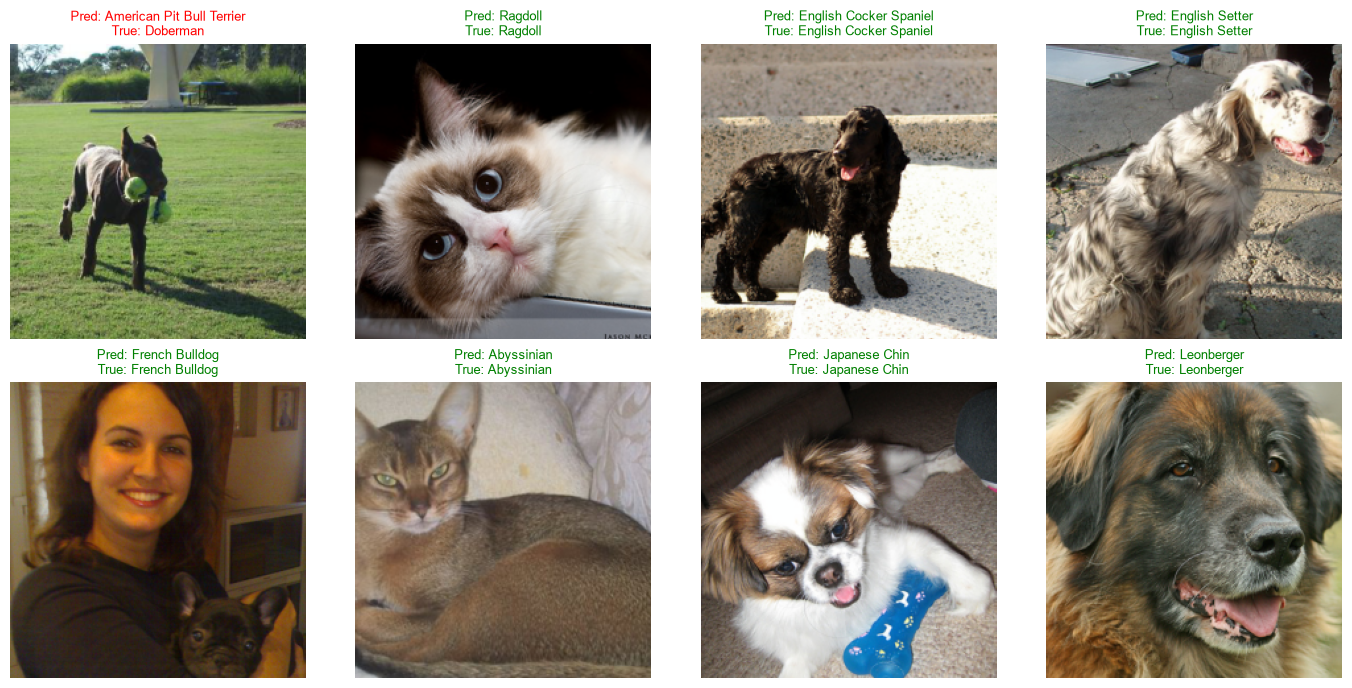

In [21]:
mean_arr, std_arr = np.array(mean), np.array(std)
sample = np.random.RandomState(1).choice(len(test_ds), 8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, i in zip(axes.ravel(), sample):
    image, _ = test_ds[i]
    ax.imshow(np.clip(image.permute(1, 2, 0).numpy() * std_arr + mean_arr, 0, 1))
    correct = y_pred[i] == y_true[i]
    ax.set_title(f"Pred: {class_names[y_pred[i]]}\nTrue: {class_names[y_true[i]]}",
                 color="green" if correct else "red", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

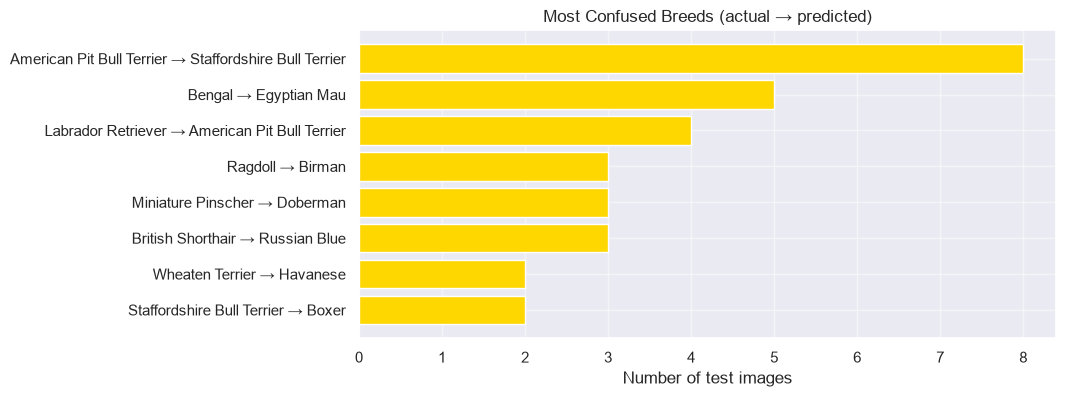

In [22]:
cm = confusion_matrix(y_true, y_pred)
np.fill_diagonal(cm, 0)                                   # keep only the mistakes
pairs = sorted(((cm[i, j], class_names[i], class_names[j]) for i, j in zip(*np.nonzero(cm))), reverse=True)[:8]

plt.figure(figsize=(9, 4))
plt.barh([f"{a} → {b}" for _, a, b in pairs][::-1], [c for c, _, _ in pairs][::-1], color="gold")
plt.title("Most Confused Breeds (actual → predicted)")
plt.xlabel("Number of test images")
plt.show()

# Evaluation

In [23]:
report = pd.DataFrame(classification_report(y_true, y_pred, target_names=class_names, output_dict=True)).T
breed_report = report.loc[class_names, ["precision", "recall", "f1-score", "support"]]

print(f"Test accuracy: {(y_pred == y_true).mean():.3f}")
breed_report.sort_values("f1-score").head(8).round(3)       # the 8 hardest breeds

Test accuracy: 0.924


,precision,recall,f1-score,support
American Pit Bull Terrier,0.739,0.567,0.642,30.0
Staffordshire Bull Terrier,0.684,0.897,0.776,29.0
Ragdoll,0.828,0.800,0.814,30.0
Bengal,0.857,0.800,0.828,30.0
Labrador Retriever,0.875,0.808,0.840,26.0
Doberman,0.833,0.870,0.851,23.0
British Shorthair,0.923,0.800,0.857,30.0
American Bulldog,0.800,0.933,0.862,30.0


In [24]:
breed_report.loc[["American Pit Bull Terrier", "Staffordshire Bull Terrier",
                  "German Shepherd", "Labrador Retriever"]].round(3)

,precision,recall,f1-score,support
American Pit Bull Terrier,0.739,0.567,0.642,30.0
Staffordshire Bull Terrier,0.684,0.897,0.776,29.0
German Shepherd,0.920,1.000,0.958,23.0
Labrador Retriever,0.875,0.808,0.840,26.0


# Saving the Model

In [25]:
artifact = {
    "architecture": "efficientnet_b0",
    "model_state": {k: v.cpu() for k, v in model.state_dict().items()},   # CPU tensors: loads on any machine
    "class_names": class_names,
    "img_size": IMG_SIZE,
    "mean": mean,
    "std": std,
    "test_accuracy": float((y_pred == y_true).mean()),
}

os.makedirs("models", exist_ok=True)
torch.save(artifact, "models/pet_breed_classifier.pth")
print("Saved to 'models/pet_breed_classifier.pth'")

Saved to 'models/pet_breed_classifier.pth'
